In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from scipy.stats import sem

In [2]:
np.random.seed(1)

In [7]:
# Creating a sample.

sample = np.array([5, 8, 9, 12, 14])

# Drawing one bootstrap sample.

bootstrap_sample = np.random.choice(
    sample,
    size=len(sample),
    replace=True
)

print(bootstrap_sample)

# Comparing bootstrap and sample mean.

print("Actual sample mean:", sample.mean())
print("Bootstap sample mean:", bootstrap_sample.mean())

[14  8  8  5  8]
Actual sample mean: 9.6
Bootstap sample mean: 8.6


In [8]:
# Creating many bootstrap samples.

bootstrap_means = []

for _ in range(10000):

    bs = np.random.choice(
        sample,
        size=len(sample),
        replace=True
    )

    bootstrap_means.append(
        bs.mean()
    )

# Converting to array.

bootstrap_means = np.array(bootstrap_means)

print(bootstrap_means[:10])

[ 8.6  7.8  8.2 10.2 10.8  8.8  7.8 11.6  7.2  9. ]


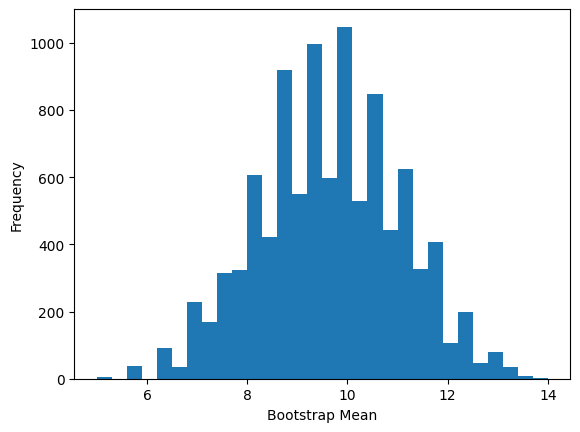

In [11]:
# Visualizing bootstrap distribution.

plt.hist(bootstrap_means, bins=30)

plt.xlabel("Bootstrap Mean")
plt.ylabel("Frequency")

plt.show()

In [22]:
# Percentile Bootstrap CI

lower = np.percentile(bootstrap_means, 2.5)

upper = np.percentile(bootstrap_means, 97.5)

print("Bootstrap CI: ", lower, upper)

# Comparing to the classical approach of CI.

mean = sample.mean()

se = sem(sample)

critical = t.ppf(
    0.975,
    len(sample)-1
)

classical_ci = [
    mean - critical*se,
    mean + critical*se
]

print("Classical CI: ", classical_ci)

Bootstrap CI:  7.0 12.4
Classical CI:  [np.float64(5.2453160093349025), np.float64(13.954683990665096)]


In [18]:
# Finding bootstap median.

bootstrap_medians = []

for _ in range(10000):

    bs = np.random.choice(
        sample,
        size=len(sample),
        replace=True
    )

    bootstrap_medians.append(
        np.median(bs)
    )

# Computing CI.

print(
    np.percentile(
        bootstrap_medians,
        [2.5, 97.5]
    )
)

[ 5. 14.]
